# Perbandingan Stabilitas Model pada Dataset Wine

Notebook ini digunakan untuk membandingkan hasil eksperimen Decision Tree, K-Nearest Neighbors (KNN), dan Random Forest pada Dataset Wine.

Perbandingan difokuskan pada:
- Rata-rata akurasi
- Akurasi minimum
- Akurasi maksimum
- Median
- Standard deviation
- Range
- Pola perubahan akurasi pada 30 random seed

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df_dt = pd.read_csv("../../results/wine/wine_decision_tree.csv")
df_knn = pd.read_csv("../../results/wine/wine_knn.csv")
df_rf = pd.read_csv("../../results/wine/wine_random_forest.csv")

## 1. Memuat Hasil Eksperimen

Hasil eksperimen masing-masing model dibaca dari file CSV agar proses perbandingan dapat dilakukan tanpa mengulang training model.

In [11]:
summary = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],
    "Mean": [
        df_dt["accuracy_percent"].mean(),
        df_knn["accuracy_percent"].mean(),
        df_rf["accuracy_percent"].mean()
    ],
    "Minimum": [
        df_dt["accuracy_percent"].min(),
        df_knn["accuracy_percent"].min(),
        df_rf["accuracy_percent"].min()
    ],
    "Maximum": [
        df_dt["accuracy_percent"].max(),
        df_knn["accuracy_percent"].max(),
        df_rf["accuracy_percent"].max()
    ],
    "Median": [
        df_dt["accuracy_percent"].median(),
        df_knn["accuracy_percent"].median(),
        df_rf["accuracy_percent"].median()
    ],
    "Std Dev": [
        df_dt["accuracy_percent"].std(),
        df_knn["accuracy_percent"].std(),
        df_rf["accuracy_percent"].std()
    ]
})

summary["Range"] = summary["Maximum"] - summary["Minimum"]

summary.round(2)

,Model,Mean,Minimum,Maximum,Median,Std Dev,Range
0,Decision Tree,90.93,80.56,97.22,91.67,3.92,16.67
1,KNN,96.57,91.67,100.00,97.22,2.15,8.33
2,Random Forest,98.61,94.44,100.00,100.00,1.59,5.56


## 2. Ringkasan Statistik

Tabel berikut menunjukkan perbandingan performa dan kestabilan ketiga algoritma.

Model dengan nilai standard deviation dan range yang lebih kecil dapat dianggap memiliki performa yang lebih konsisten terhadap perubahan pembagian data.

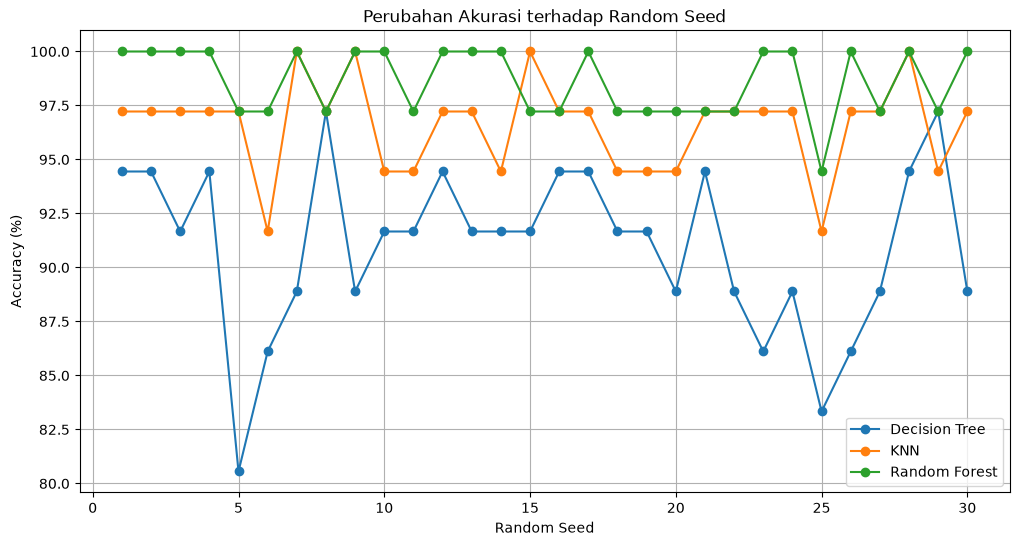

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_dt["seed"],
    df_dt["accuracy_percent"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    df_knn["seed"],
    df_knn["accuracy_percent"],
    marker="o",
    label="KNN"
)

plt.plot(
    df_rf["seed"],
    df_rf["accuracy_percent"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Random Seed")
plt.ylabel("Accuracy (%)")
plt.title("Perubahan Akurasi terhadap Random Seed")
plt.legend()
plt.grid(True)

plt.show()

## 3. Perubahan Akurasi pada Setiap Random Seed

Grafik menunjukkan bagaimana akurasi masing-masing model berubah ketika komposisi data training dan testing diubah melalui random seed yang berbeda.

Model yang memiliki garis lebih stabil menunjukkan sensitivitas yang lebih rendah terhadap perubahan train-test split.

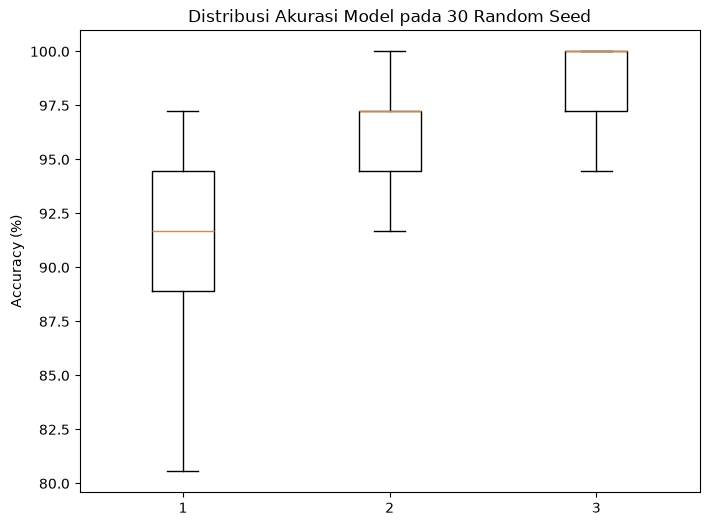

In [13]:
data_boxplot = [
    df_dt["accuracy_percent"],
    df_knn["accuracy_percent"],
    df_rf["accuracy_percent"]
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    data_boxplot,
    label=[
        "Decision Tree",
        "KNN",
        "Random Forest"
    ]
)

plt.ylabel("Accuracy (%)")
plt.title("Distribusi Akurasi Model pada 30 Random Seed")

plt.show()

## 4. Distribusi Akurasi

Boxplot digunakan untuk melihat penyebaran hasil akurasi pada setiap model.

Model dengan distribusi yang lebih sempit menunjukkan hasil yang lebih konsisten, sedangkan distribusi yang lebih lebar menunjukkan sensitivitas yang lebih besar terhadap perubahan train-test split.

## 5. Analisis Hasil

Berdasarkan 30 variasi random seed, ketiga model menunjukkan tingkat kestabilan yang berbeda.

Decision Tree memiliki variasi akurasi paling besar. Akurasinya berubah dari sekitar 80.56% hingga 97.22%, sehingga menunjukkan sensitivitas yang relatif tinggi terhadap perubahan pembagian data.

KNN menunjukkan hasil yang lebih stabil dibandingkan Decision Tree. Akurasinya berada pada rentang sekitar 91.67% hingga 100%, dengan standard deviation yang lebih rendah.

Random Forest menunjukkan performa paling konsisten pada Dataset Wine. Selain memiliki rata-rata akurasi tertinggi, Random Forest juga memiliki standard deviation dan range paling kecil dibandingkan kedua model lainnya.

Hasil ini menunjukkan bahwa perubahan komposisi data training dan testing dapat memengaruhi performa model, tetapi tingkat sensitivitasnya berbeda antaralgoritma.

In [14]:
summary.to_csv(
    "../../results/wine/wine_model_summary.csv",
    index=False
)